# Nested CV: Pearson r per fold (LOIO)

This notebook loads three result files:
- `outputs/nested_cv/nested_cv_loio_gcn_summary.json`
- `outputs/nested_cv/nested_cv_nograph_results.json`
- `outputs/nested_cv/nested_cv_loio_ensemble_gcn_results.json`

It then visualizes the per-fold Pearson correlation for each side by side in the same figure. The loader supports multiple JSON schemas (legacy and new).

In [2]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from typing import List, Dict, Tuple, Any, Optional


# ------------------------- Robust loader utilities -------------------------
LABEL_ORDER = [
    'MLP', 'GCN', 'GraphSAGE',
    'MLP Ensemble', 'GCN Ensemble', 'GraphSAGE Ensemble',
    'GCN Inductive', 'GraphSAGE Inductive',
    'GBLUP', 'Ridge', 'No graph'
]

LABEL_COLOR_MAP = {
    'MLP': '#4C78A8',
    'GCN': '#F58518',
    'GraphSAGE': '#54A24B',
    'MLP Ensemble': '#E45756',
    'GCN Ensemble': '#B279A2',
    'GraphSAGE Ensemble': '#72B7B2',
    'GCN Inductive': '#FF9DA6',
    'GraphSAGE Inductive': '#9D755D',
    'GBLUP': '#BAB0AC',
    'Ridge': '#8C564B',
    'No graph': '#B5BD61',
}


def _extract_corr_values(payload: Any) -> List[float]:
    """Extract Pearson r values from multiple known JSON schemas."""
    if isinstance(payload, dict):
        # Most common schema in this project
        arr = payload.get('outer_test_corr', None)
        if isinstance(arr, list):
            vals = [float(x) for x in arr if x is not None and np.isfinite(float(x))]
            if vals:
                return vals

        # Alternative per-fold schema
        per_fold = payload.get('per_fold', None)
        if isinstance(per_fold, list):
            vals = []
            for row in per_fold:
                if isinstance(row, dict) and 'pearson_r' in row and row['pearson_r'] is not None:
                    vals.append(float(row['pearson_r']))
            if vals:
                return vals

        # Other possible keys used in prior exports
        for key in ['pearson_r', 'corr_eval', 'correlations', 'fold_corrs', 'test_corrs']:
            val = payload.get(key, None)
            if isinstance(val, list):
                vals = [float(x) for x in val if x is not None and np.isfinite(float(x))]
                if vals:
                    return vals

        # Recursive scan fallback
        vals = []
        for v in payload.values():
            vals.extend(_extract_corr_values(v))
        return vals

    if isinstance(payload, list):
        vals = []
        for it in payload:
            if isinstance(it, (int, float)):
                if np.isfinite(float(it)):
                    vals.append(float(it))
            else:
                vals.extend(_extract_corr_values(it))
        return vals

    return []


def load_one(path: str, label: str) -> Dict[str, Any]:
    """Load a single nested CV JSON result into standard format."""
    p = Path(path)
    if not p.exists():
        print(f'[WARN] Missing file for {label}: {p}')
        return {'label': label, 'path': str(p), 'df': pd.DataFrame({'pearson_r': []})}

    with open(p, 'r', encoding='utf-8') as f:
        payload = json.load(f)

    vals = _extract_corr_values(payload)
    if len(vals) == 0:
        print(f'[WARN] No correlation values parsed for {label}: {p}')

    return {
        'label': label,
        'path': str(p),
        'df': pd.DataFrame({'pearson_r': vals})
    }


def load_many(labels_path: Dict[str, str]) -> List[Dict[str, Any]]:
    """Load many model outputs from a {label: path} mapping."""
    results: List[Dict[str, Any]] = []
    for label, path in labels_path.items():
        results.append(load_one(path, label))

    # Stable sort by preferred order, then label name
    order_map = {k: i for i, k in enumerate(LABEL_ORDER)}
    results = sorted(results, key=lambda d: (order_map.get(d['label'], 999), d['label']))
    return results

In [3]:
BOXPLOT_STYLE = {
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.titleweight": "normal",
    "axes.titlepad": 14,
    "axes.labelsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
}


In [4]:
def plot_phenotype_single_axis(
    panel_specs: List[Dict[str, Any]],
    title: str,
    outfile: Optional[str] = None,
    figsize: Tuple[float, float] = (12.5, 5.5),
    grid_step: Optional[float] = 0.1,
    label_step: Optional[float] = None,
) -> None:
    """Render one figure with phenotypes on the x-axis and model boxes as hue."""

    rows: List[Dict[str, Any]] = []
    label_sequence: List[str] = []
    phenotype_order: List[str] = []
    for spec in panel_specs:
        phenotype = spec.get("panel_label") or spec.get("title")
        if phenotype is None:
            continue
        phenotype_order.append(phenotype)
        for res in spec.get("results", []):
            label = res["label"]
            if label not in label_sequence:
                label_sequence.append(label)
            values = res["df"].get("pearson_r")
            if values is None:
                continue
            for val in values:
                rows.append({"Phenotype": phenotype, "Model": label, "Correlation": val})

    if not rows:
        raise ValueError("No data available to plot.")

    long_df = pd.DataFrame(rows)
    hue_order = [label for label in LABEL_ORDER if label in long_df["Model"].unique()]
    missing = [label for label in label_sequence if label not in hue_order]
    hue_order.extend(missing)
    palette = [LABEL_COLOR_MAP.get(label, "#a0a0a0") for label in hue_order]

    label_step = label_step if label_step is not None else grid_step

    with plt.rc_context(BOXPLOT_STYLE):
        fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
        sns.boxplot(
            data=long_df,
            x="Phenotype",
            y="Correlation",
            hue="Model",
            order=phenotype_order,
            hue_order=hue_order,
            palette=palette,
            linewidth=1.1,
            fliersize=4.0,
            ax=ax,
        )

        ax.set_title(title, fontsize=18)
        ax.set_xlabel("")
        ax.set_ylabel("Correlation", fontsize=14)
        ax.set_facecolor("#fdfdfd")
        for spine in ax.spines.values():
            spine.set_visible(False)

        if label_step:
            ax.yaxis.set_major_locator(MultipleLocator(label_step))
        if grid_step:
            ax.yaxis.set_minor_locator(MultipleLocator(grid_step))
            if not np.isclose(grid_step, label_step or grid_step):
                ax.tick_params(axis="y", which="minor", length=0)
        ax.tick_params(axis="y", which="major", length=4)

        grid_kwargs = dict(axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
        ax.grid(which="major", **grid_kwargs)
        if grid_step and not np.isclose(grid_step, label_step or grid_step):
            ax.grid(which="minor", **grid_kwargs)

        handles, labels = ax.get_legend_handles_labels()
        legend_labels = [lbl.replace(" ", "\n") if " " in lbl else lbl for lbl in labels]
        ax.legend(
            handles=handles,
            labels=legend_labels,
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            borderaxespad=0.6,
            prop={"size": 11},
        )

        if outfile:
            out_path = Path(outfile)
            if out_path.parent and str(out_path.parent) != ".":
                out_path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(out_path, dpi=300, bbox_inches="tight")
            print(f"Saved figure to {out_path}")
        plt.show()

# Across population

## Tarsus Length

In [5]:
labels = ['MLP', 'GCN', 'GraphSAGE', 'MLP Ensemble', 'GraphSAGE Ensemble', 'GBLUP', 'Ridge']
base_path = '../outputs/nested_cv/thr_tarsus/loio'
labels_path = {'MLP': f'{base_path}/mlp_results.json',
               'GCN': f'{base_path}/gcn_results.json',
               'GraphSAGE': f'{base_path}/sage_results.json',
               'MLP Ensemble': f'{base_path}/mlp_ens_results.json',
               'GraphSAGE Ensemble': f'{base_path}/ens_sage_results.json',
                'GCN Inductive': f'{base_path}/gcn_inductive_results.json',
                'GraphSAGE Inductive': f'{base_path}/sage_inductive_results.json',
               'GBLUP': f'{base_path}/gblup_aase_results.json',
               'Ridge': f'{base_path}/ridge_results.json'}  # --- IGNORE ---

loio_results = load_many(labels_path)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results ]

[('MLP',
     pearson_r
  0   0.299649
  1   0.327693
  2   0.236379
  3   0.285372
  4   0.231031),
 ('GCN',
     pearson_r
  0   0.337562
  1   0.321279
  2   0.224257
  3   0.321721
  4   0.204368),
 ('GraphSAGE',
     pearson_r
  0   0.259259
  1   0.404182
  2   0.197616
  3   0.272427
  4   0.256181),
 ('MLP Ensemble',
     pearson_r
  0   0.328396
  1   0.247521
  2   0.217832
  3   0.254469
  4   0.217187),
 ('GraphSAGE Ensemble',
     pearson_r
  0   0.314988
  1   0.279527
  2   0.209347
  3   0.319256
  4   0.180348),
 ('GCN Inductive',
     pearson_r
  0   0.200483
  1   0.330070
  2   0.174740
  3   0.293885
  4   0.215191),
 ('GraphSAGE Inductive',
     pearson_r
  0   0.235413
  1   0.435629
  2   0.219629
  3   0.289640
  4   0.226585),
 ('GBLUP',
     pearson_r
  0     0.1125
  1     0.2520
  2     0.2272
  3     0.1998
  4     0.2200),
 ('Ridge',
     pearson_r
  0   0.254103
  1   0.346257
  2   0.236272
  3   0.271992
  4   0.241478)]

## Body Mass

In [6]:
labels_body = ['MLP', 'GCN', 'GraphSAGE', 'MLP Ensemble', 'GCN Ensemble', 'GraphSAGE Ensemble', 'GBLUP', 'Ridge']
base_path_body = '../outputs/nested_cv/body_mass/loio'
labels_path_body = {
    'MLP': f'{base_path_body}/mlp_results.json',
    'GCN': f'{base_path_body}/gcn_results.json',
    'GraphSAGE': f'{base_path_body}/sage_results.json',
    'MLP Ensemble': f'{base_path_body}/mlp_ens_results.json',
    'GraphSAGE Ensemble': f'{base_path_body}/ens_sage_results.json',
    'GCN Inductive': f'{base_path_body}/gcn_inductive_results.json',
    'GraphSAGE Inductive': f'{base_path_body}/sage_inductive_results.json',
    'GBLUP': f'{base_path_body}/gblup_aase_results.json',
    'Ridge': f'{base_path_body}/ridge_results.json'
}

loio_results_body = load_many(labels_path_body)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results_body ]

[('MLP',
     pearson_r
  0   0.201026
  1   0.388593
  2   0.149661
  3   0.174978
  4   0.104949),
 ('GCN',
     pearson_r
  0   0.251862
  1   0.205945
  2   0.161535
  3   0.209417
  4   0.061864),
 ('GraphSAGE',
     pearson_r
  0     0.2448
  1     0.3718
  2     0.1737
  3     0.2310
  4     0.1153),
 ('MLP Ensemble',
     pearson_r
  0   0.255356
  1   0.317215
  2   0.186943
  3   0.213236
  4   0.134819),
 ('GraphSAGE Ensemble',
     pearson_r
  0   0.228669
  1   0.453528
  2   0.158698
  3   0.215068
  4   0.173397),
 ('GCN Inductive',
     pearson_r
  0   0.185367
  1   0.383662
  2   0.167795
  3   0.185808
  4   0.102896),
 ('GraphSAGE Inductive',
     pearson_r
  0   0.231871
  1   0.444149
  2   0.161150
  3   0.203354
  4   0.111936),
 ('GBLUP',
     pearson_r
  0     0.2050
  1     0.4300
  2     0.1458
  3     0.1760
  4     0.0800),
 ('Ridge',
     pearson_r
  0   0.233912
  1   0.444455
  2   0.176661
  3   0.197133
  4   0.105656)]

## Wing length

In [7]:
labels_wing = ['No graph', 'GCN', 'GraphSAGE', 'GBLUP', 'Ridge']
base_path_wing = '../outputs/nested_cv/thr_wing/loio'
labels_path_wing = {
    'MLP Ensemble': f'{base_path_wing}/mlp_ens_results.json',
    'GraphSAGE Ensemble': f'{base_path_wing}/ens_sage_results.json',
    'MLP': f'{base_path_wing}/mlp_results.json',
    'GCN': f'{base_path_wing}/gcn_results.json',
    'GraphSAGE': f'{base_path_wing}/sage_results.json',
    'GCN Inductive': f'{base_path_wing}/gcn_inductive_results.json',
    'GraphSAGE Inductive': f'{base_path_wing}/sage_inductive_results.json',
    'GBLUP': f'{base_path_wing}/gblup_aase_results.json',
    'Ridge': f'{base_path_wing}/ridge_results.json'
}

loio_results_wing = load_many(labels_path_wing)
# Show heads for sanity
[ (r['label'], r['df'].head()) for r in loio_results_wing ]

[('MLP',
     pearson_r
  0   0.194766
  1   0.227563
  2   0.243119
  3   0.357564
  4   0.098402),
 ('GCN',
     pearson_r
  0   0.155661
  1   0.229653
  2   0.251189
  3   0.311960
  4   0.122658),
 ('GraphSAGE',
     pearson_r
  0   0.218713
  1   0.241346
  2   0.261488
  3   0.302767
  4   0.077877),
 ('MLP Ensemble',
     pearson_r
  0   0.167837
  1   0.174907
  2   0.247334
  3   0.337966
  4   0.116599),
 ('GraphSAGE Ensemble',
     pearson_r
  0   0.200911
  1   0.177614
  2   0.252920
  3   0.370401
  4   0.109210),
 ('GCN Inductive',
     pearson_r
  0   0.113015
  1   0.291049
  2   0.217260
  3   0.340328
  4   0.082905),
 ('GraphSAGE Inductive',
     pearson_r
  0   0.162758
  1   0.284800
  2   0.231892
  3   0.322981
  4   0.066768),
 ('GBLUP',
     pearson_r
  0     0.0896
  1     0.3807
  2     0.1430
  3     0.3100
  4     0.1456),
 ('Ridge',
     pearson_r
  0   0.146409
  1   0.188196
  2   0.239964
  3   0.374563
  4   0.123060)]

Saved figure to ..\figures\loio_single_panel.pdf


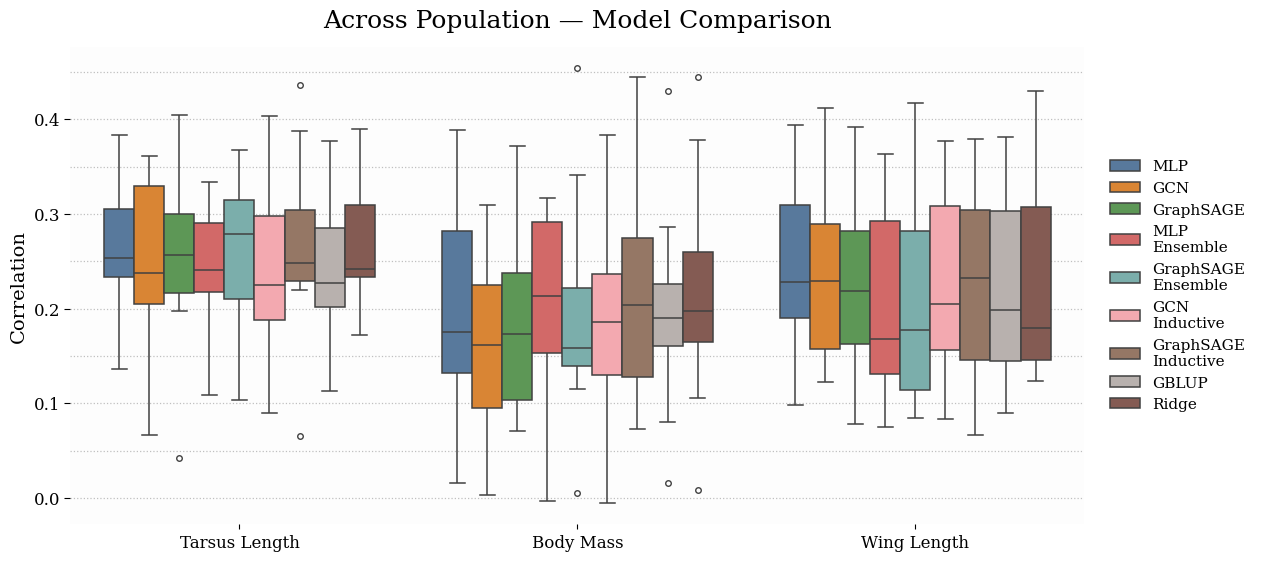

In [8]:
loio_panel_specs = [
    {
        "panel_label": "Tarsus Length",
        "results": loio_results,
    },
    {
        "panel_label": "Body Mass",
        "results": loio_results_body,
    },
    {
        "panel_label": "Wing Length",
        "results": loio_results_wing,
    },
]

plot_phenotype_single_axis(
    loio_panel_specs,
    title="Across Population — Model Comparison",
    outfile="../figures/loio_single_panel.pdf",
    figsize=(12.5, 5.5),
    grid_step=0.05,
    label_step=0.1,
)


## Within vs Across (GBLUP)

Compare within-population vs across-population (LOIO) performance using only GBLUP.

Saved figure to ..\figures\gblup_within_vs_across.pdf


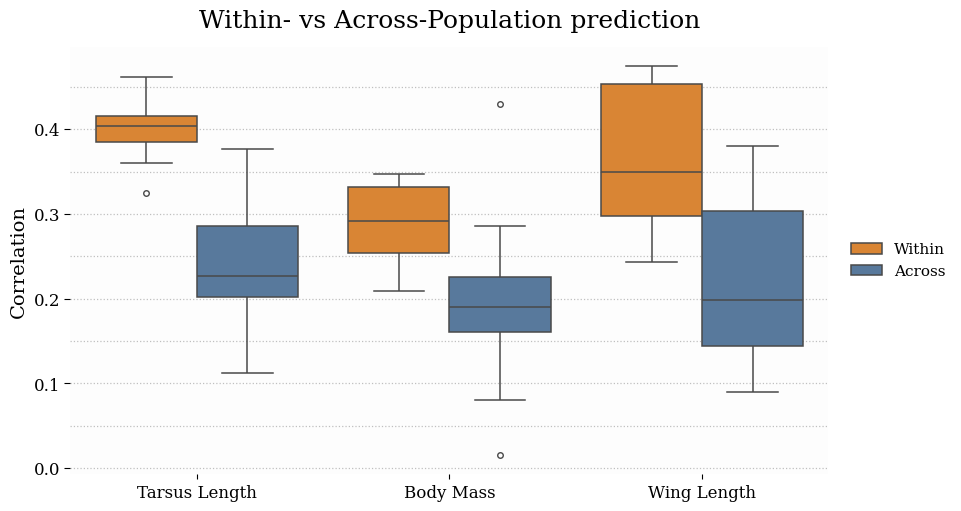

In [14]:
phenotypes = [
    ("thr_tarsus", "Tarsus Length"),
    ("body_mass", "Body Mass"),
    ("thr_wing", "Wing Length"),
]

rows = []
for key, label in phenotypes:
    across = load_one(f"../outputs/nested_cv/{key}/loio/gblup_aase_results.json", "Across")
    within = load_one(f"../outputs/nested_cv/{key}/within/gblup_aase_results.json", "Within")

    for res in (across, within):
        values = res["df"].get("pearson_r")
        if values is None:
            continue
        for val in values:
            rows.append(
                {
                    "Phenotype": label,
                    "CV Strategy": res["label"],
                    "Correlation": val,
                }
            )

if not rows:
    raise ValueError("No GBLUP data found for within/across comparison.")

long_df = pd.DataFrame(rows)

palette = {
    "Within": "#F58518",
    "Across": "#4C78A8",
}

with plt.rc_context(BOXPLOT_STYLE):
    fig, ax = plt.subplots(figsize=(9.5, 5.0), constrained_layout=True)
    sns.boxplot(
        data=long_df,
        x="Phenotype",
        y="Correlation",
        hue="CV Strategy",
        order=[p[1] for p in phenotypes],
        hue_order=["Within", "Across"],
        palette=palette,
        linewidth=1.1,
        fliersize=4.0,
        ax=ax,
    )

    ax.set_title("Within- vs Across-Population prediction", fontsize=18)
    ax.set_xlabel("")
    ax.set_ylabel("Correlation", fontsize=14)
    ax.set_facecolor("#fdfdfd")
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_minor_locator(MultipleLocator(0.05))
    ax.tick_params(axis="y", which="major", length=4)
    ax.tick_params(axis="y", which="minor", length=0)

    grid_kwargs = dict(axis="y", linestyle=":", linewidth=0.9, color="#b9b9b9", alpha=0.9)
    ax.grid(which="major", **grid_kwargs)
    ax.grid(which="minor", **grid_kwargs)

    ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.01, 0.5), borderaxespad=0.6, prop={"size": 11})

    out_path = Path("../figures/gblup_within_vs_across.pdf")
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    print(f"Saved figure to {out_path}")

    plt.show()